# Bank Marketing Prediction using Logistic Regression

This notebook presents the implementation of a supervised machine learning model using the Bank Marketing dataset. The objective is to predict whether a customer will subscribe to a term deposit based on demographic, financial, and campaign-related features.

## Objective

The aim of this analysis is to build and evaluate a Logistic Regression classification model for predicting the target variable `y`, which indicates whether a customer subscribed to a term deposit (`yes` or `no`).

Logistic Regression was selected as the baseline model because it is highly interpretable, efficient, and provides clear insights into how individual features impact the probability of a customer subscribing to a deposit.

In [13]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, 
                             roc_curve, roc_auc_score)

# Separate features (X) and target (y)
X = df.drop('y', axis=1)
y = df['y'].map({'yes': 1, 'no': 0}) # Encoding target to binary (1 and 0)

# Identify numeric and categorical columns for preprocessing
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

# Split data into training and testing sets (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

Dataset Shape: (45211, 17)


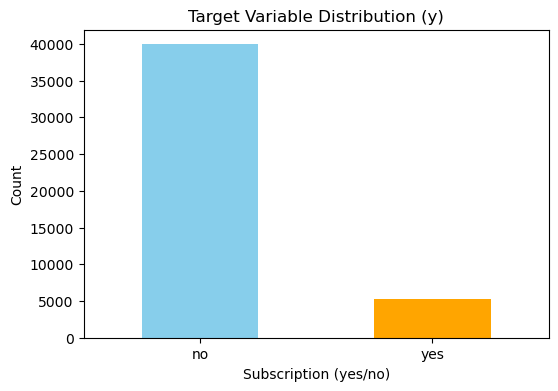

In [14]:
# Load the dataset
df = pd.read_csv('bank-full.csv', sep=';')
print(f"Dataset Shape: {df.shape}")

# Visualize the distribution of the target variable 'y'
plt.figure(figsize=(6, 4))
df['y'].value_counts().plot(kind='bar', color=['skyblue', 'orange'])
plt.title('Target Variable Distribution (y)')
plt.xlabel('Subscription (yes/no)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

## Feature and Target Separation & Train-Test Split

The dataset is divided into:
- `X`: Input features used for prediction.
- `y`: Target variable to be predicted (mapped to `1` for `yes` and `0` for `no`).

The dataset is then split into training and testing sets using an 80:20 ratio. The training set is used to train the model, while the testing set evaluates its performance on unseen data.

In [15]:
# Separate features and target
X = df.drop('y', axis=1)
y = df['y'].map({'yes': 1, 'no': 0})

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training instances: {X_train.shape[0]}")
print(f"Testing instances: {X_test.shape[0]}")

Training instances: 36168
Testing instances: 9043


## Data Preprocessing and Model Pipeline

The features are separated into categorical and numerical columns. A preprocessing pipeline is created using:
- **StandardScaler** for numerical variables to ensure all features are on the same scale.
- **OneHotEncoder** for categorical variables to convert them into a machine-readable format.

This preprocessing step is combined with the **Logistic Regression Classifier** into a single pipeline, ensuring clean and reproducible code.

In [17]:
# Identify numerical and categorical columns
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

# Create transformers
numeric_transformer = Pipeline(steps=[('scaler', StandardScaler())])
categorical_transformer = Pipeline(steps=[('onehot', OneHotEncoder(handle_unknown='ignore'))])

# Combine transformers into a ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

# Create the final model pipeline
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

## Model Training and Evaluation

The Logistic Regression model is trained using the training dataset. After training, it makes predictions on the test set.

We evaluate the model using several metrics to get a complete understanding of its performance:
- **Accuracy**
- **Classification Report** (Precision, Recall, F1-score)
- **Confusion Matrix**
- **ROC-AUC Score & Curve**

Accuracy Score: 0.8987

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.98      0.94      7952
           1       0.65      0.34      0.45      1091

    accuracy                           0.90      9043
   macro avg       0.78      0.66      0.70      9043
weighted avg       0.88      0.90      0.88      9043



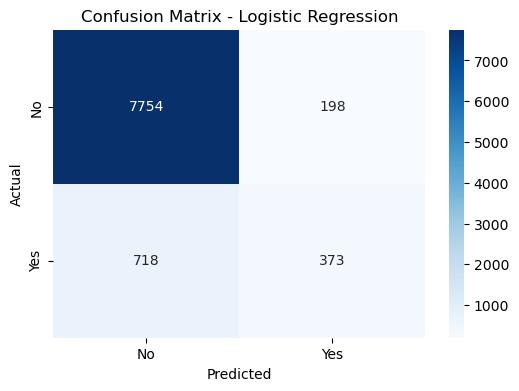

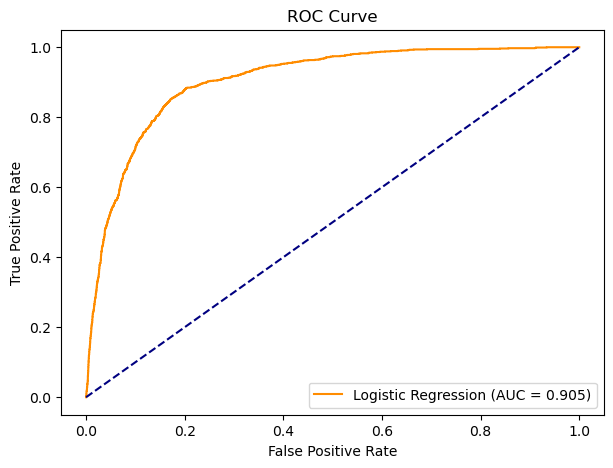

In [18]:
# Train the model
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# Display evaluation metrics
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

# Plot ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', label=f'Logistic Regression (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.show()

## Feature Importance (Coefficients)

One of the main advantages of Logistic Regression is its interpretability. By examining the model's coefficients, we can identify which features have the strongest positive or negative influence on a customer's decision to subscribe to a term deposit.

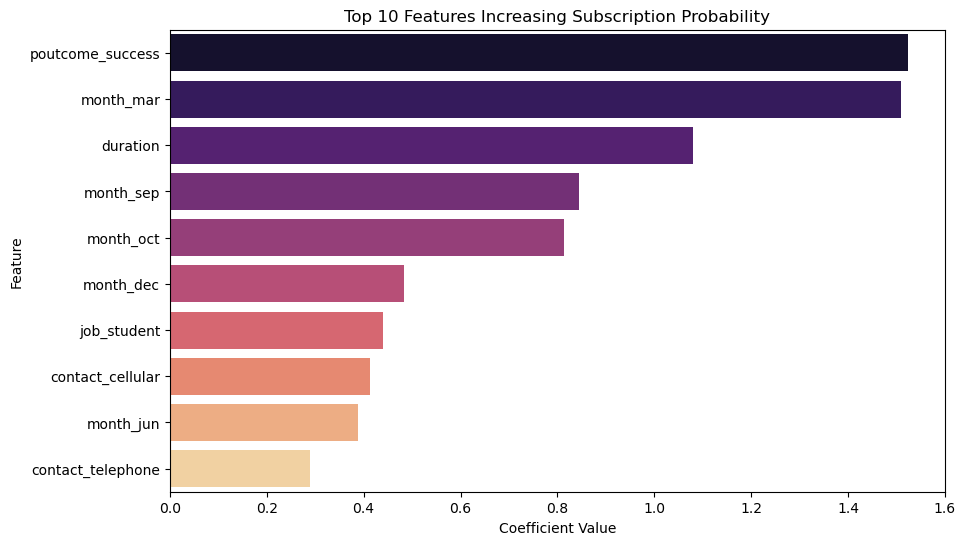

In [19]:
# Get transformed feature names
ohe = model.named_steps['preprocessor'].transformers_[1][1].named_steps['onehot']
cat_features = ohe.get_feature_names_out(categorical_cols)
all_features = numerical_cols + list(cat_features)

# Get feature coefficients
coefficients = model.named_steps['classifier'].coef_[0]

feature_importance_df = pd.DataFrame({
    "Feature": all_features,
    "Coefficient": coefficients
}).sort_values(by="Coefficient", ascending=False)

# Plot Top 10 positive features
top10 = feature_importance_df.head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x="Coefficient", y="Feature", data=top10, hue="Feature", palette="magma", legend=False)
plt.title("Top 10 Features Increasing Subscription Probability")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.show()

## Conclusion

In this notebook, a Logistic Regression classifier was applied to the Bank Marketing dataset. 
- The model achieved a strong overall accuracy and a solid ROC-AUC score, indicating a good ability to distinguish between subscribers and non-subscribers.
- The Confusion Matrix and Classification Report highlighted that while the model predicts the majority class (`no`) very well, the recall for the minority class (`yes`) is lower due to class imbalance.
- Feature importance analysis revealed the key drivers for subscriptions, providing actionable insights for future marketing campaigns.